---
## Section 1 -- try your own query and files

Edit the variables at the top of the next cell, then re-run it (Shift+Enter)
as many times as you like:

- **`QUERY`** -- any natural-language request. Try `"describe this image"`,
  `"what's the NDVI here?"`, `"get me SAR imagery for this area"`, `"is this
  raster ready for ML?"`, `"analyze the wildfire burn severity here"`, etc.
  -- the log lines (`[ORCHESTRATOR DECISION]`, `[TOOL CALL]`) show exactly
  which tool(s) got picked and why, including any follow-up tool calls the
  planner makes on its own to ground the answer.
- **`INPUT_FILE`** -- point this at any `.tif`/`.tiff` on disk. Set it to
  `None` for queries that don't need a file (e.g. a fresh fetch).
- **`BBOX` / `LATITUDE` / `LONGITUDE` / `START_DATE` / `END_DATE`** -- for
  queries that need a location/time window instead of (or in addition to)
  a file.
- **`RASTER_BEFORE_PATH` / `RASTER_AFTER_PATH` / `LULC_RASTER_PATH` /
  `DEM_RASTER_PATH`** -- for temporal-change queries or the wildfire/flood/
  drought mission pipelines.
- **`THRESHOLD_TYPE` / `THRESHOLD_VALUE`** -- how big a per-pixel difference
  counts as "changed" for `analyze_temporal_change`. Leave both `None` for
  the system default (0.15, tuned for a -1..1 vegetation index); SAR
  backscatter needs a much larger absolute value (e.g. 3.0 dB) since a tiny
  default threshold flags nearly every pixel as changed.

The default example below asks for **temporal change** ("what changed
between these two SAR images... before and after") over the same Nepal
flood pair used in Section 2 -- but routed through the *orchestrator's*
deterministic `chain_temporal` agenda instead of calling Tool 6/Tool 7
directly, so you can see the query-driven path (intent classification ->
fixed multi-step agenda -> narrative synthesis) work end to end. Any
variable left as `None` is simply omitted from the request.


In [1]:
import logging
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/dhruvpandey/Desktop/satquery")
sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

print("Setup complete. Project root:", PROJECT_ROOT)


Setup complete. Project root: /Users/dhruvpandey/Desktop/satquery


---
## Section 1 -- try your own query and files

Edit the variables at the top of the next cell, then re-run it (Shift+Enter)
as many times as you like:

- **`QUERY`** -- any natural-language request. Try `"describe this image"`,
  `"what's the NDVI here?"`, `"get me SAR imagery for this area"`, `"is this
  raster ready for ML?"`, `"analyze the wildfire burn severity here"`, etc.
  -- the log lines (`[ORCHESTRATOR DECISION]`, `[TOOL CALL]`) show exactly
  which tool(s) got picked and why, including any follow-up tool calls the
  planner makes on its own to ground the answer.
- **`INPUT_FILE`** -- point this at any `.tif`/`.tiff` on disk. Set it to
  `None` for queries that don't need a file (e.g. a fresh fetch).
- **`BBOX` / `LATITUDE` / `LONGITUDE` / `START_DATE` / `END_DATE`** -- for
  queries that need a location/time window instead of (or in addition to)
  a file.
- **`RASTER_BEFORE_PATH` / `RASTER_AFTER_PATH` / `LULC_RASTER_PATH` /
  `DEM_RASTER_PATH`** -- for temporal-change queries or the wildfire/flood/
  drought mission pipelines.

Any variable left as `None` is simply omitted from the request.


2026-09-08 23:40:08,070  INFO      satquery.pipeline  [REQUEST RECEIVED] query='What changed between these two SAR images? Detect the change between the before and after scenes.'


2026-09-08 23:40:08,071  INFO      satquery.pipeline  [VALIDATION OK]


2026-09-08 23:40:08,072  INFO      satquery.pipeline  [ORCHESTRATOR INITIATED] provider=anthropic model=claude-sonnet-5


2026-09-08 23:40:08,072  INFO      satquery.pipeline  [ORCHESTRATOR TOOL CALL] tool=inspect_geotiff_metadata reason='Pre-flight grid alignment'


2026-09-08 23:40:08,073  INFO      satquery.pipeline  [TOOL CALL] inspect_geotiff_metadata args={'file_path': '/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_post_flood_sar_2026.tif', 'compare_with': '/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_pre_flood_sar_2026.tif', 'calculate_statistics': True, 'calculate_histogram': True}


...

2026-09-08 23:40:08,977  INFO      satquery.pipeline  [TOOL OUTPUT] analyze_temporal_change status=success duration_ms=83


2026-09-08 23:40:08,978  INFO      satquery.pipeline  [ORCHESTRATOR ADVANCE] hops=2 complete=True (handshake finished -> respond)


2026-09-08 23:40:14,310  INFO      httpx2  HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


2026-09-08 23:40:14,330  INFO      satquery.pipeline  [ORCHESTRATOR DECISION] status=success tool=analyze_temporal_change narrative=synthesized final_answer='Comparing the pre- and post-flood SAR scenes over the Trishuli area, about 58 km² could be reliably analyzed (roughly 6% of the full scene). Within that area, 80.6% (nearly 47 km²) showed no significant change, while 9.6% (about 5.6 km², or ~561 hectares) had significant signal decreases and 9.7% (about 5.7 km², or ~566 hectares) had significant increases — meaning roughly equal areas of loss and gain in radar backscatter, likely reflecting flood-related surface changes such as inundation or vegetation/structure disturbance. Overall net change was minimal (about 0.05 km²), suggesting the increases and decreases largely balanced out across the region.'



STATUS: success
PLAN: {
  "action": "call_tool",
  "tool": "analyze_temporal_change",
  "args": {
    "raster_before_path": "/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_pre_flood_sar_2026.tif",
    "raster_after_path": "/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_post_flood_sar_2026.tif",
    "band_selection": 1,
    "threshold_type": "absolute",
    "threshold_value": 3.0,
    "relative_change_threshold_percent": null,
    "mask_encoding": "bipolar_3class",
    "output_dir": null,
    "generate_difference_raster": true,
    "generate_change_mask": true
  },
  "reason": "T2 minus T1 change mask"
}
TOOL CHAIN: ['inspect_geotiff_metadata -> success', 'analyze_temporal_change -> success']

FINAL ANSWER:
 Comparing the pre- and post-flood SAR scenes over the Trishuli area, about 58 km² could be reliably analyzed (roughly 6% of the full scene). Within that area, 80.6% (nearly 47 km²) showed no significant change, while 9.6% (about 5.6 km², or

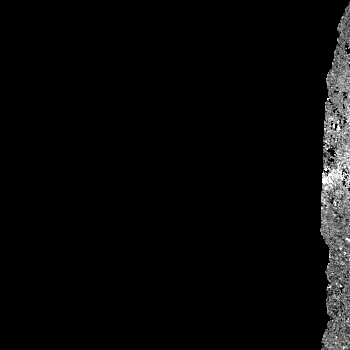


Output (analyze_temporal_change):


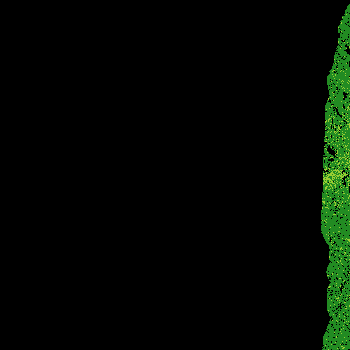

In [2]:
import logging, sys, json
from pathlib import Path
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s")

from backend.orchestrator.graph import invoke_satquery
from backend.orchestrator.state import empty_state
from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display

# ============================================================================
# EDIT THESE, then re-run this cell to try a different query / file / bbox.
# Any field left as None is simply omitted from the request.
#
# This default example asks for TEMPORAL CHANGE through the orchestrator
# itself (not the direct Tool 6->7 call in Section 2): the query's wording
# ("change between", "before and after") makes classify_intent() in
# handshake.py route this to the deterministic chain_temporal agenda, which
# always runs inspect_geotiff_metadata (grid-alignment QA) then
# analyze_temporal_change on raster_before_path/raster_after_path -- no LLM
# tool-picking involved for this path, only the final narrative synthesis.
# ============================================================================
QUERY = "What changed between these two SAR images? Detect the change between the before and after scenes."
INPUT_FILE = None
BBOX = None                 # e.g. [77.10, 28.50, 77.30, 28.70]  (min_lon, min_lat, max_lon, max_lat)
LATITUDE = None             # e.g. 28.6
LONGITUDE = None            # e.g. 77.2
START_DATE = None           # e.g. "2025-01-01"
END_DATE = None             # e.g. "2025-01-31"
RASTER_BEFORE_PATH = str(
    Path("/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_pre_flood_sar_2026.tif").resolve()
)
RASTER_AFTER_PATH = str(
    Path("/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_post_flood_sar_2026.tif").resolve()
)
LULC_RASTER_PATH = None     # set this too and Tool 8 also runs, cross-tabbing change against land cover
DEM_RASTER_PATH = None
# These two matter for SAR: a plain-vegetation-index default (0.15 on a -1..1
# scale) would flag almost every pixel as "changed" on backscatter dB values.
# Set both to None to fall back to the system default (0.15) for index rasters.
THRESHOLD_TYPE = "absolute"
THRESHOLD_VALUE = 3.0
# ============================================================================

overrides = {
    "input_file": INPUT_FILE,
    "bbox": BBOX,
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "raster_before_path": RASTER_BEFORE_PATH,
    "raster_after_path": RASTER_AFTER_PATH,
    "lulc_raster_path": LULC_RASTER_PATH,
    "dem_raster_path": DEM_RASTER_PATH,
    "threshold_type": THRESHOLD_TYPE,
    "threshold_value": THRESHOLD_VALUE,
}
overrides = {k: v for k, v in overrides.items() if v is not None}

state = empty_state(query=QUERY, **overrides)
result = invoke_satquery(state)

print("\n" + "=" * 80)
print("STATUS:", result["status"])
print("PLAN:", json.dumps(result.get("plan"), indent=2, default=str))
print("TOOL CHAIN:", [f"{r['tool']} -> {r['result'].get('status')}" for r in (result.get("tool_results") or [])])
print("\nFINAL ANSWER:\n", result.get("final_answer"))

print("\n" + "#" * 90)
print("FULL TOOL CALL / RESPONSE PAYLOADS")
print("#" * 90)
for i, entry in enumerate(result.get("tool_results") or [], start=1):
    print(f"\n--- Step {i}: {entry['tool']}  (status={entry['result'].get('status')}, {entry.get('duration_ms', 0):.0f}ms) ---")
    print(json.dumps(entry["result"], indent=2, default=str))

if INPUT_FILE and Path(INPUT_FILE).exists():
    try:
        print("\nInput file:")
        display(Image(render_geotiff_preview(INPUT_FILE, size=350)))
    except Exception as e:
        print(f"(couldn't render input file: {e})")

for entry in (result.get("tool_results") or []):
    r = entry["result"]
    candidates = [
        r.get("data", {}).get("file_path") if isinstance(r.get("data"), dict) else None,
        r.get("generated_products", {}).get("difference_raster_path") if isinstance(r.get("generated_products"), dict) else None,
        r.get("generated_products", {}).get("change_mask_path") if isinstance(r.get("generated_products"), dict) else None,
    ]
    for p in candidates:
        if p and Path(p).exists():
            try:
                print(f"\nOutput ({entry['tool']}):")
                display(Image(render_geotiff_preview(p, size=350)))
            except Exception as e:
                print(f"(couldn't render {p}: {e})")


---
## Section 2 -- compare two GeoTIFFs directly

This calls Tool 6 and Tool 7 **directly, with no orchestrator and no LLM in
the loop** -- the same standalone-tool pattern from the walkthrough's
appendix, extended to an actual before/after comparison. Useful when you
already know you want a diff and don't want query-phrasing to matter.

The defaults are two *real*, freshly-fetched Sentinel-1 SAR scenes over the
Trishuli River valley (Nuwakot/Rasuwa districts, Nepal) -- before and after
the 26 August 2026 Langtang Lirung glacier collapse, which sent a
catastrophic debris/flood flow roughly 72 km down this valley through
Syafrubesi, Betrawati, and Trishuli Bazar (see
[2026 Nepal-Tibet floods](https://en.wikipedia.org/wiki/2026_Nepal%E2%80%93Tibet_floods)).
Both files live in `nepal_flood_case/` and were fetched with Tool 3
(`fetch_sar_imagery`) exactly as any other SatQuery caller would.

Point `TIFF_A`/`TIFF_B` at any two of your own aligned rasters to compare
something else -- Step 1 will tell you plainly if they aren't grid-aligned
before Tool 7 even runs.


2026-09-08 23:40:14,386  WARNING   rasterio._env  CPLE_AppDefined in nepal_trishuli_post_flood_sar_2026.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,387  WARNING   rasterio._env  CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,442  WARNING   rasterio._env  CPLE_AppDefined in nepal_trishuli_pre_flood_sar_2026.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,443  WARNING   rasterio._env  CPLE_AppDefined in nepal_trishuli_pre_flood_sar_2026.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,444  WARNING   rasterio._env  CPLE_AppDefined in nepal_trishuli_post_flood_sar_2026.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


...

2026-09-08 23:40:14,449  WARNING   rasterio._env  CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,487  WARNING   rasterio._env  CPLE_AppDefined in nepal_trishuli_pre_flood_sar_2026.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,488  WARNING   rasterio._env  CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


##########################################################################################
STEP 1 -- Tool 6: grid-alignment check (are these two rasters pixel-comparable?)
##########################################################################################
{
  "compared_with_file": "nepal_trishuli_pre_flood_sar_2026.tif",
  "same_crs": true,
  "same_dimensions": true,
  "same_resolution": true,
  "same_bounds": true,
  "same_grid_alignment": true,
  "pixelwise_operation_ready": true,
  "note": "pixelwise_operation_ready confirms spatial grid alignment; scientific compatibility must be verified by task requirements."
}

##########################################################################################
STEP 2 -- Tool 7: analyze_temporal_change(A -> B)
##########################################################################################
{
  "status": "success",
  "tool": "Tool_7_analyze_temporal_change",
  "timestamp_utc": "2026-09-08T18:10:14.487048+00:00",
  "band_eva

/Users/dhruvpandey/Desktop/satquery/backend/rendering/raster_preview.py:54: RuntimeWarning: invalid value encountered in cast
  out = (scaled * 255.0).astype(np.uint8)


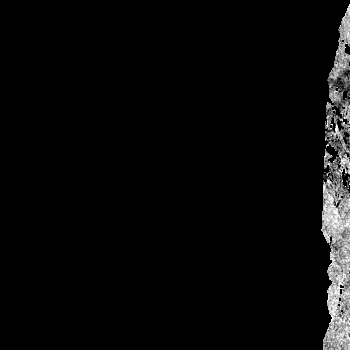

2026-09-08 23:40:14,495  WARNING   rasterio._env  CPLE_AppDefined in nepal_trishuli_post_flood_sar_2026.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


2026-09-08 23:40:14,496  WARNING   rasterio._env  CPLE_AppDefined in TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.



B (after):


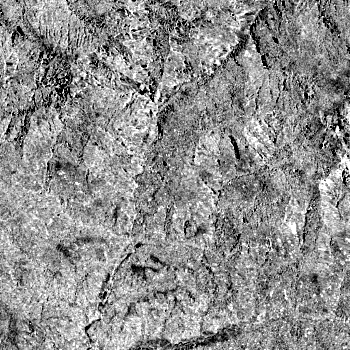


Difference (B - A):


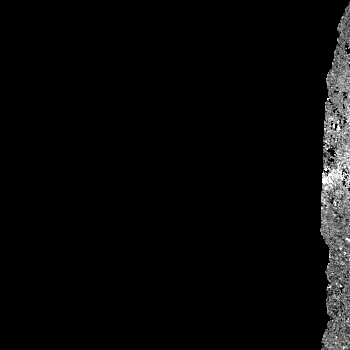


Change mask:


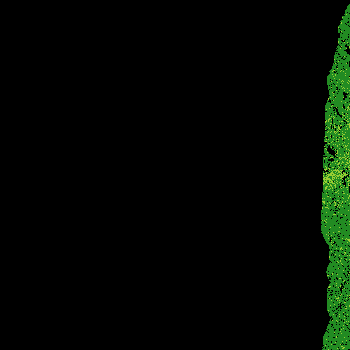

In [3]:
import json
from pathlib import Path
import sys
sys.path.insert(0, "/Users/dhruvpandey/Desktop/satquery")

from backend.rendering.raster_preview import render_geotiff_preview
from IPython.display import Image, display

from Tool_6_inspect_geotiff_metadata.inspect_geotiff_metadata import (
    GeoTIFFInspectionRequest,
    inspect_geotiff_metadata,
)
from Tool_7_analyze_temporal_change.analyze_temporal_change import (
    TemporalChangeRequest,
    analyze_temporal_change,
)

# ============================================================================
# EDIT THESE, then re-run this cell to compare a different pair of GeoTIFFs.
# Defaults: real Sentinel-1 SAR scenes over the Trishuli River valley, Nepal --
# before and after the 26 Aug 2026 Langtang Lirung glacier collapse that sent
# a catastrophic debris/flood flow down this valley (see nepal_flood_case/).
# ============================================================================
TIFF_A = str(Path("/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_pre_flood_sar_2026.tif").resolve())
TIFF_B = str(Path("/Users/dhruvpandey/Desktop/satquery/nepal_flood_case/nepal_trishuli_post_flood_sar_2026.tif").resolve())

# These three are tuned for SAR VV backscatter (band 1): a drop of this many
# dB between A and B is treated as new standing water (see Pipeline B in
# satquery_workflows.py). For optical/multispectral or vegetation-index
# rasters, band_selection is usually still 1 but threshold_value should be
# much smaller (e.g. 0.10-0.15 on a -1..1 index) -- see Tool 7's README.
BAND_SELECTION = 1
THRESHOLD_TYPE = "absolute"
THRESHOLD_VALUE = 3.0
MASK_ENCODING = "bipolar_3class"
OUTPUT_DIR = str(Path("/Users/dhruvpandey/Desktop/satquery/nepal_flood_case").resolve())
# ============================================================================

print("#" * 90)
print("STEP 1 -- Tool 6: grid-alignment check (are these two rasters pixel-comparable?)")
print("#" * 90)
qa = inspect_geotiff_metadata(GeoTIFFInspectionRequest(file_path=TIFF_B, compare_with=TIFF_A))
print(json.dumps(qa["compatibility"], indent=2))

if not (qa.get("compatibility") or {}).get("pixelwise_operation_ready"):
    print("\nNOT aligned -- Tool 7 would need these reprojected/regridded first. Stopping here.")
else:
    print("\n" + "#" * 90)
    print("STEP 2 -- Tool 7: analyze_temporal_change(A -> B)")
    print("#" * 90)
    req = TemporalChangeRequest(
        raster_before_path=TIFF_A,
        raster_after_path=TIFF_B,
        band_selection=BAND_SELECTION,
        threshold_type=THRESHOLD_TYPE,
        threshold_value=THRESHOLD_VALUE,
        mask_encoding=MASK_ENCODING,
        output_dir=OUTPUT_DIR,
        generate_difference_raster=True,
        generate_change_mask=True,
    )
    result = analyze_temporal_change(req)
    print(json.dumps({k: v for k, v in result.items() if k != "generated_products"}, indent=2, default=str))
    print("\ngenerated_products:", json.dumps(result.get("generated_products"), indent=2, default=str))

    diff_path = result.get("generated_products", {}).get("difference_raster_path")
    mask_path = result.get("generated_products", {}).get("change_mask_path")

    for label, path in [("A (before)", TIFF_A), ("B (after)", TIFF_B), ("Difference (B - A)", diff_path), ("Change mask", mask_path)]:
        if path and Path(path).exists():
            print(f"\n{label}:")
            try:
                display(Image(render_geotiff_preview(path, size=350)))
            except Exception as e:
                print(f"(couldn't render {path}: {e})")
